<a href="https://colab.research.google.com/github/devikarajeev770-afk/AI-ML-Course/blob/main/MNIST_using_CNN(optimization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification of Handwritten digits in MNIST dataset through CNN

This is a Keras implementation of a CNN neural network model. More details about keras API is available in the documentation <https://keras.io/getting-started/sequential-model-guide/>

> The MLP code shown below solves a binary classification problem.

> This script also prints Area Under Curve (AUC) and plots a Receiver Operating Characteristic (ROC) curve at the end.

>**Step 1:** First, import all the Python modules.
From Keras, import the Sequential model as well as the Dense, Dropout and the Activation layers. Also import roc_curve and auc from sklearn.

In [ ]:
# loading libraries
import numpy as np
from __future__ import print_function
import pandas as pd
import matplotlib.pyplot as plt
# Importing both TensorFlow and its high level API - Keras.
import tensorflow as tf
from tensorflow import keras
# Setting the random seeds for repeatability
tf.random.set_seed(1)
np.random.seed(42)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Conv2D, BatchNormalization,MaxPooling2D, Flatten
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.optimizers import RMSprop

## Loading dataset and split for training and testing

Shape of X_train:  (60000, 28, 28)
Shape of X_test:  (10000, 28, 28)


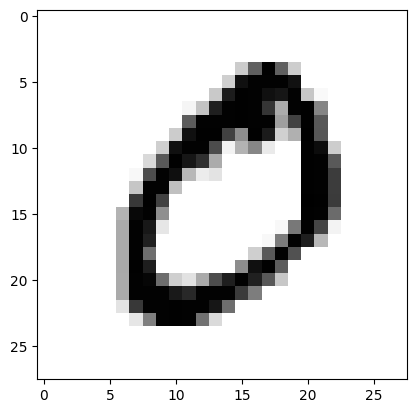

In [ ]:
# Load MNIST database of handwritten digits
mnistDB = keras.datasets.mnist
# Training Dataset of 60,000 28x28 grayscale images of the 10 digits,
# along with a test set of 10,000 images.
(X_train, y_train),(X_test, y_test) = mnistDB.load_data()
print("Shape of X_train: ", X_train.shape)
# Shape of X_train:  (60000, 28, 28)
print("Shape of X_test: ", X_test.shape)
# Shape of X_test:  (10000, 28, 28)
# We can view the dataset with matplotlib
plt.imshow(X_train[1], cmap='binary')
plt.show()

In [ ]:
X_train = X_train.reshape((60000, 28,28,1))
X_test = X_test.reshape((10000, 28,28,1))

>**Normalizing pixel values**:  The grayscale image pixels are unsigned values between 0 and 255. These pixels need to be normalized to the range 0 to 1 for DNN.  So, the entire training data is converted to 32-bit float and then divided with 255 to bring down the range to 0 to 1. Similar operations are done to 10000 testing images.



# Check again the shape of both training and testing dataset.

In [ ]:
# Scale pixel values to range 0 to 1.
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [ ]:
print("Shape of X_train: ", X_train.shape)
# Shape of X_train:  (60000, 28,28,1)
print("Shape of X_test: ", X_test.shape)
# Shape of X_test:  (10000, 28,28,1)

Shape of X_train:  (60000, 28, 28, 1)
Shape of X_test:  (10000, 28, 28, 1)


>**Step 2**: Below is the Python module that initializes the neural network.
It comprises a Sequential model that has A block of convolutional and maxpooling  sparse layers, where each layer is followed by an Activation layer.
Note that I used Dropout layer only after the convolution layers. The convolution layer followed with a flatten layer and further a Deep Neural net.
The first two Activation layers in the DNN block have ‘relu’ as the activation function.
For the last Activation layer, I used ‘softmax’ because it is a multi class classification problem.
I used Stochastic Gradient Descent with Nesterov momentum for training.
Typically, ‘categorical_crossentropy’ is used for multi class classification problems.

In [ ]:
num_classes=10
model = Sequential()
model.add(Conv2D(32,(3,3), activation="relu", input_shape=X_train.shape[1:]))
model.add(MaxPooling2D((2,2)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation="relu"))
# Here begins the fully connected part (DNN) of ConvNet
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.1))
model.add(Dense(32, activation="relu"))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,466 (372.91 KB)

 Trainable params: 95,274 (372.16 KB)

 Non-trainable params: 192 (768.00 B)

>**Step 3:** Generate the Neural Network

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
#optimizer=RMSprop() also can be used

## Visualizing the model

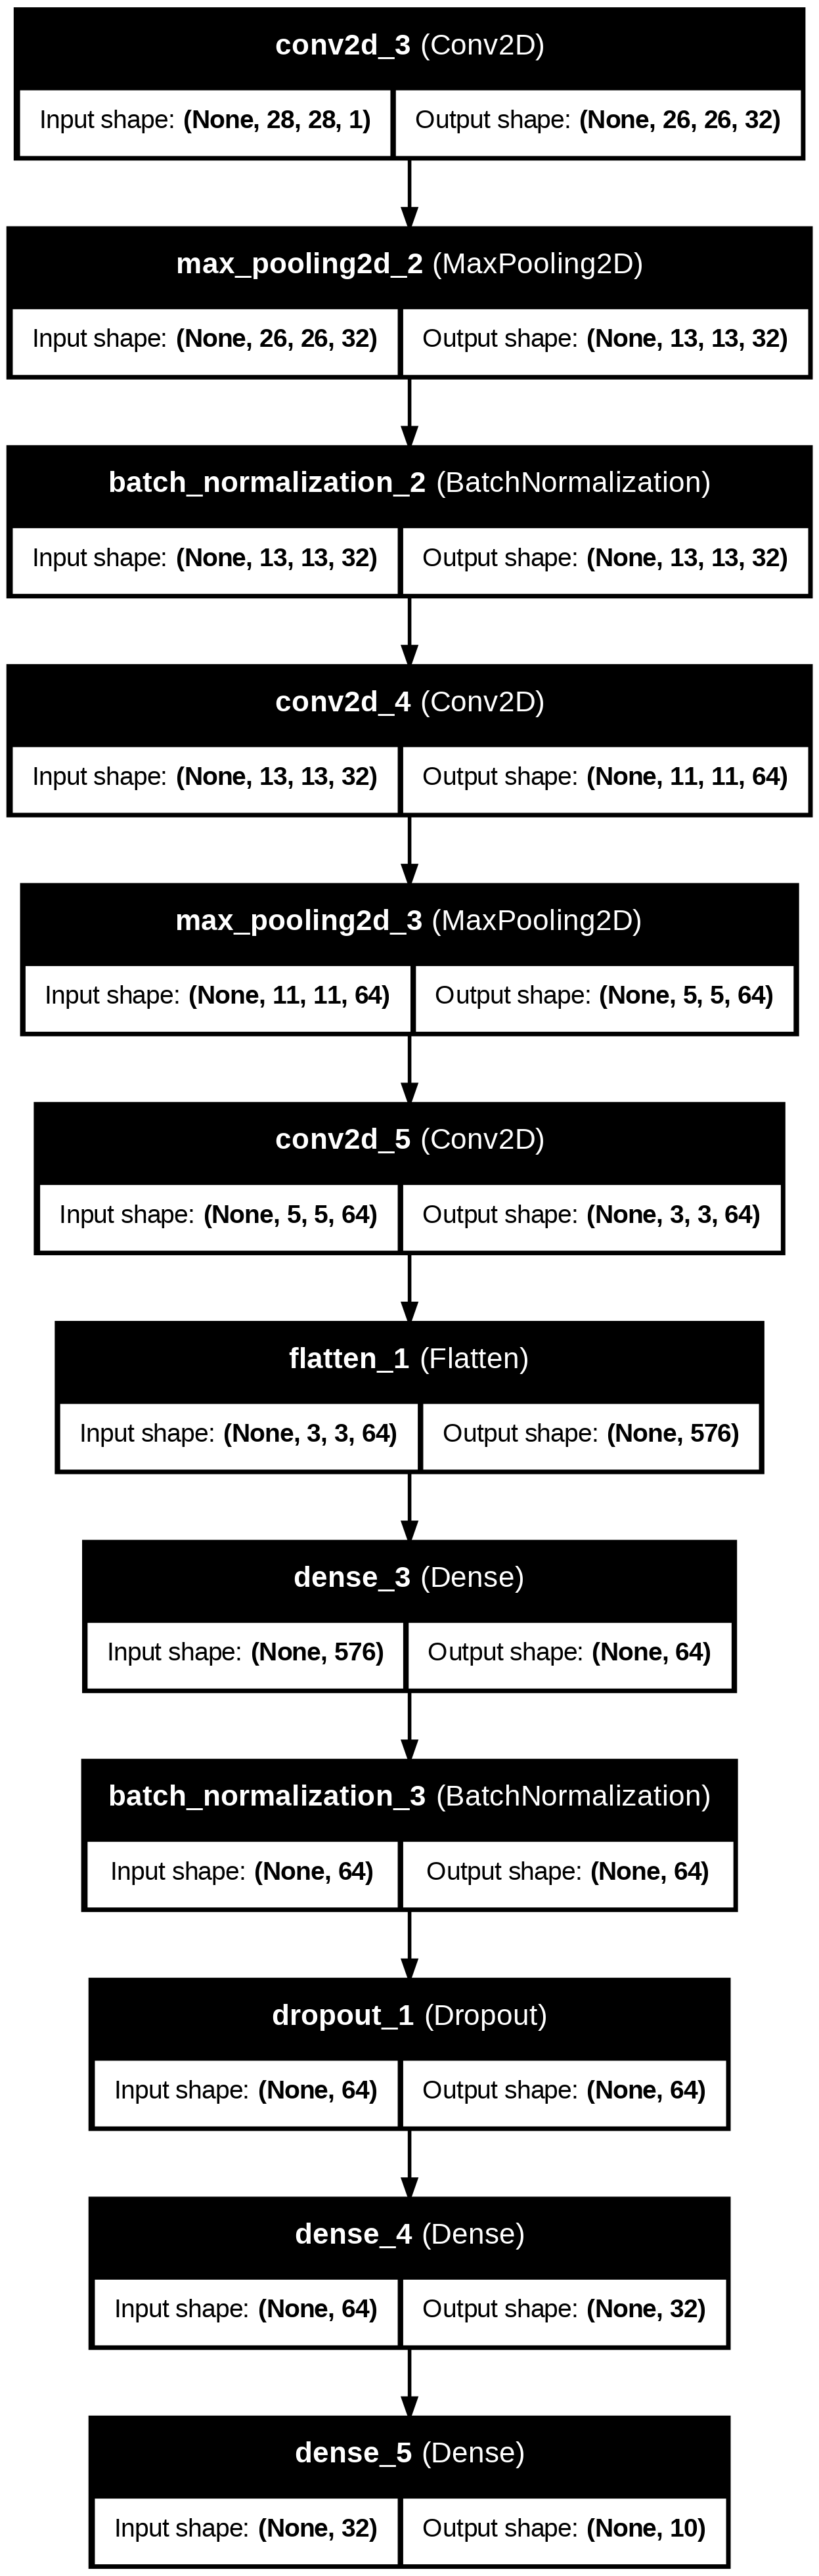

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png',show_shapes=True, show_layer_names=True)

>**Step 4:**  Conversion of target set to categorical variables

In [ ]:
# Generate dummy data and fix hyper parameters
batch_size = 128
num_classes = 10
epochs = 20


# convert class vectors to binary class matrices
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [ ]:
cb_early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=10,
                                                  restore_best_weights=True)
cb_model_checkpoint = keras.callbacks.ModelCheckpoint("bestModel_MNIST.h5",
                                                      save_best_only=True)
history = model.fit(x=X_train, y=y_train, validation_split=0.1, epochs=10,
batch_size=16,callbacks=[cb_early_stopping,cb_model_checkpoint])

Epoch 1/10
3372/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9095 - loss: 0.3285

3375/3375 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - accuracy: 0.9524 - loss: 0.1664 - val_accuracy: 0.9735 - val_loss: 0.0888
Epoch 2/10
3374/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9782 - loss: 0.0748

3375/3375 ━━━━━━━━━━━━━━━━━━━━ 80s 14ms/step - accuracy: 0.9787 - loss: 0.0715 - val_accuracy: 0.9867 - val_loss: 0.0470
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.9832 - loss: 0.0543 - val_accuracy: 0.9867 - val_loss: 0.0531
Epoch 4/10
3371/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9885 - loss: 0.0381

3375/3375 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - accuracy: 0.9883 - loss: 0.0391 - val_accuracy: 0.9895 - val_loss: 0.0397
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 81s 14ms/step - accuracy: 0.9902 - loss: 0.0314 - val_accuracy: 0.9890 - val_loss: 0.0405
Epoch 6/10
3372/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9920 - loss: 0.0243

3375/3375 ━━━━━━━━━━━━━━━━━━━━ 80s 14ms/step - accuracy: 0.9919 - loss: 0.0251 - val_accuracy: 0.9913 - val_loss: 0.0368
Epoch 7/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.9931 - loss: 0.0207 - val_accuracy: 0.9908 - val_loss: 0.0402
Epoch 8/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.9941 - loss: 0.0183 - val_accuracy: 0.9910 - val_loss: 0.0413
Epoch 9/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9903 - val_loss: 0.0462
Epoch 10/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - accuracy: 0.9953 - loss: 0.0140 - val_accuracy: 0.9897 - val_loss: 0.0443


## Displaying the learning of the network

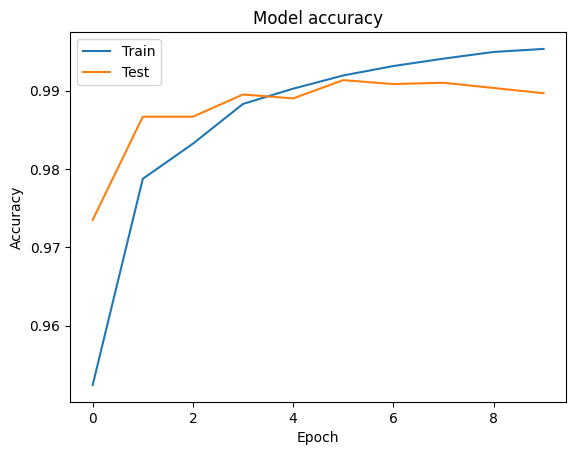

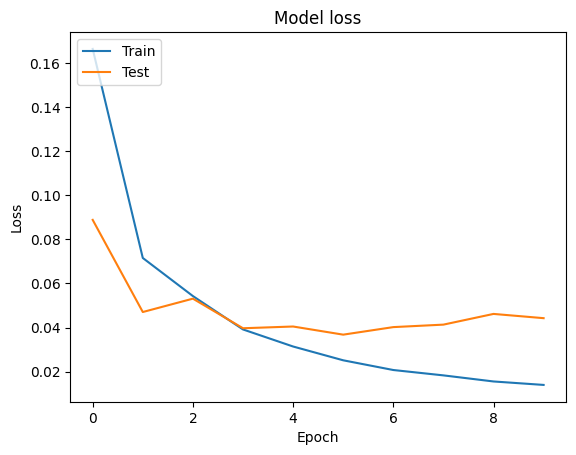

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

>**Step 6:** Evaluate the model on test set and print the error and accuracy scores

In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.03322547301650047
Test accuracy: 0.9908000230789185


In [ ]:
y_pred = model.predict(X_test)
#y_pred=y_pred>0.5
from sklearn.metrics import confusion_matrix
y_pred=np.argmax(y_pred, axis=1)
#print(y_pred)
#y_pred.shape
y_temp=y_test>0.5
y_temp=np.argmax(y_temp,axis=1)
cm = confusion_matrix(y_true = y_temp, y_pred=y_pred)
print(cm)
#y_temp.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
[[ 977    0    1    0    0    0    1    1    0    0]
 [   0 1131    1    3    0    0    0    0    0    0]
 [   1    1 1019    5    0    0    0    4    2    0]
 [   0    0    0 1005    0    3    0    1    1    0]
 [   0    0    1    0  973    0    0    0    0    8]
 [   0    0    0    8    0  874    3    0    4    3]
 [   5    3    2    1    1    1  942    0    3    0]
 [   0    3    2    0    0    0    0 1019    1    3]
 [   1    0    1    2    0    0    0    0  969    1]
 [   0    0    1    1    2    2    0    1    3  999]]
